In [2]:
import joblib
model = joblib.load('../models/lightgbm_best.pkl')
print(model.feature_name_)
print(mejor_modelo.feature_name_)


['NetFractionRevolvingBurden', 'ExternalRiskEstimate', 'AverageMInFile', 'PercentTradesWBalance', 'MSinceOldestTradeOpen', 'NumSatisfactoryTrades', 'PercentInstallTrades', 'MSinceMostRecentInqexcl7days']


NameError: name 'mejor_modelo' is not defined

In [1]:
from pathlib import Path
import pandas as pd

ROOT           = Path().resolve().parent
DATA_PROCESSED = ROOT / 'data' / 'raw'

df = pd.read_csv(DATA_PROCESSED / "heloc_dataset.csv")
df["target"] =  (df['RiskPerformance'] == 'Bad').astype(int)

df.head()

,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,target
0,Bad,55,144,4,84,20,3,0,83,2,...,0,0,0,33,-8,8,1,1,69,1
1,Bad,61,58,15,41,2,4,4,100,-7,...,0,0,0,0,-8,0,-8,-8,0,1
2,Bad,67,66,5,24,9,0,0,100,-7,...,0,4,4,53,66,4,2,1,86,1
3,Bad,66,169,1,73,28,1,1,93,76,...,0,5,4,72,83,6,4,3,91,1
4,Bad,81,333,27,132,12,0,0,100,-7,...,0,1,1,51,89,3,1,0,80,1


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['RiskPerformance', 'target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)
modelo_lr.fit(X_train, y_train)

y_pred = modelo_lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f'Regresión Logística AUC: {auc:.4f}')

Regresión Logística AUC: 0.7549


C:\Users\sampa\anaconda3\envs\credit-risk\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
import lightgbm as lgb

modelo_lgb = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
modelo_lgb.fit(X_train, y_train)

y_pred_lgb = modelo_lgb.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)
print(f'LightGBM AUC: {auc_lgb:.4f}')

[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 8367, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM AUC: 0.7868


In [5]:
import xgboost as xgb
modelo_xgb = xgb.XGBClassifier(scale_pos_weight=1, random_state=42, eval_metric="auc")
modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)
print(f"XGBoost AUC: {auc_xgb:.4f}")

XGBoost AUC: 0.7734


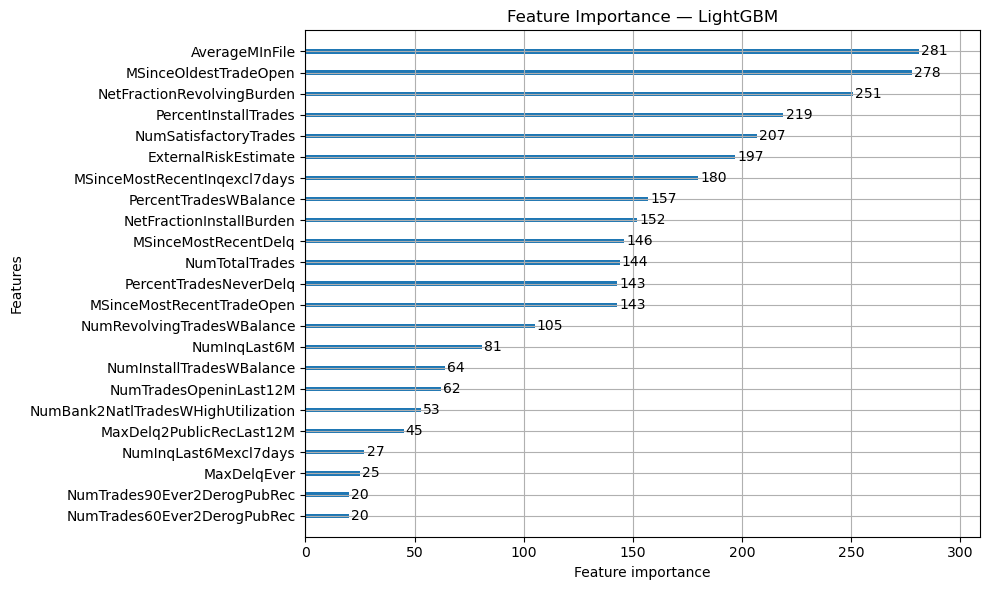

In [6]:
import matplotlib.pyplot as plt

lgb.plot_importance(modelo_lgb, figsize=(10, 6), title='Feature Importance — LightGBM')
plt.tight_layout()
plt.show()

### MLFlow - Rastreo

In [7]:
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

# Definir experimento
mlflow.set_experiment('credit-risk-heloc')

print('MLflow listo')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

MLflow listo
Tracking URI: sqlite:///C:/Users/sampa/Downloads/credit_risk_ml/notebooks/mlflow.db


In [8]:
import numpy as np

def calcular_metricas(y_test, y_pred_proba):
    auc  = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * auc - 1

    # KS statistic
    from scipy.stats import ks_2samp
    ks = ks_2samp(y_pred_proba[y_test == 1], y_pred_proba[y_test == 0]).statistic

    return {'auc': round(auc, 4), 'gini': round(gini, 4), 'ks': round(ks, 4)}

print('Métricas definidas')

Métricas definidas


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

In [10]:
modelos = {
    "LogisticRegression" : LogisticRegression(class_weight = 'balanced', random_state=42, max_iter=1000),
    "RandomForest": RandomForestClassifier(class_weight = 'balanced', random_state=42, n_estimators=100),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric="auc"),
    "LightGBM": lgb.LGBMClassifier(class_weight="balanced", random_state=42),
    "LightGBM_FeatureSelection": Pipeline([
        ("selector", SelectKBest(f_classif, k=5)),
        ("model", lgb.LGBMClassifier(class_weight="balanced",  random_state=42))
    ])
}

In [11]:
for nombre, modelo in modelos.items():
    with mlflow.start_run(run_name=nombre):
        ## entrenar modelos
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict_proba(X_test)[:,1]

        ##metricas
        metricas = calcular_metricas(y_test, y_pred)

        
        ## loggear en mlflow
        mlflow.log_metrics(metricas)
        mlflow.log_param("modelo", nombre)
        print(f'{nombre:35} AUC: {metricas["auc"]}  Gini: {metricas["gini"]}  KS: {metricas["ks"]}')

print('\n Todos los modelos loggeados en MLflow')

C:\Users\sampa\anaconda3\envs\credit-risk\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression                  AUC: 0.7736  Gini: 0.5471  KS: 0.4225
RandomForest                        AUC: 0.7909  Gini: 0.5818  KS: 0.4464
XGBoost                             AUC: 0.7734  Gini: 0.5468  KS: 0.4244
[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 8367, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM                            AUC: 0.7868  Gini: 0.5736  KS: 0.4416
[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing 

C:\Users\sampa\anaconda3\envs\credit-risk\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [12]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100
)

In [13]:
###pip install optuna

In [14]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objetivo(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth':     trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':  trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':  'balanced',
        'random_state':  42
    }

    modelo = RandomForestClassifier(**params)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=10)

print(f'Mejor AUC: {study.best_value:.4f}')
print(f'Mejores parámetros: {study.best_params}')

Mejor AUC: 0.7958
Mejores parámetros: {'n_estimators': 240, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}


In [15]:
# entrenar modelo final con los mejores parámetros
mejor_modelo = lgb.LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42
)

with mlflow.start_run(run_name='LightGBM_BEST'):
    mejor_modelo.fit(X_train, y_train)
    y_pred = mejor_modelo.predict_proba(X_test)[:, 1]
    metricas = calcular_metricas(y_test, y_pred)

    mlflow.log_params(study.best_params)
    mlflow.log_metrics(metricas)
    mlflow.lightgbm.log_model(mejor_modelo, 'modelo_final')

    print(f' Mejor modelo registrado en MLflow')
    print(f'   AUC:  {metricas["auc"]}')
    print(f'   Gini: {metricas["gini"]}')
    print(f'   KS:   {metricas["ks"]}')

[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=6. Current value: min_data_in_leaf=6
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=6. Current value: min_data_in_leaf=6
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Info] Number of positive: 4367, number of negative: 4000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 8367, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> i

2026/03/08 21:31:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=6. Current value: min_data_in_leaf=6
[LightGBM] [Warning] Unknown parameter: max_features


2026/03/08 21:31:09 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Mejor modelo registrado en MLflow
   AUC:  0.7813
   Gini: 0.5627
   KS:   0.4296


In [16]:
import joblib
### guardar modelo en el disco
joblib.dump(mejor_modelo, ROOT/'models/lightgbm_best.pkl')
print(' Modelo guardado en models/lightgbm_best.pkl')
print(mejor_modelo.feature_name_)


 Modelo guardado en models/lightgbm_best.pkl
